In [33]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from itertools import combinations
from sklearn.base import clone
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import scipy
import matplotlib.patheffects as PathEffects
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split, learning_curve, validation_curve, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, precision_score, matthews_corrcoef, recall_score, f1_score, make_scorer, roc_curve, roc_auc_score, auc

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'
'machine-learning-databases'
'/breast-cancer-wisconsin/wdbc.data', header=None)
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [3]:
df.isnull().sum()[:24]

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
dtype: int64

In [4]:
df.isnull().sum()[24:]

24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
dtype: int64

In [5]:
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [6]:
le.transform(['B', 'M'])

array([0, 1])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [8]:
pipe_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression())
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print(f"The Score accuracy {pipe_lr.score(X_test, y_test):0.3f}")


The Score accuracy 0.956


In [9]:
k_fold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []
for k, (train, test) in enumerate(k_fold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print(f"{scores[k]:0.5f}")
print(f"Mean of Scores list: {np.mean(scores):0.5f}")
print(f"Varaince of Scores list: {np.std(scores):0.5f}")

0.93478
0.93478
0.95652
0.95652
0.93478
0.95556
0.97778
0.93333
0.95556
0.95556
Mean of Scores list: 0.94952
Varaince of Scores list: 0.01385


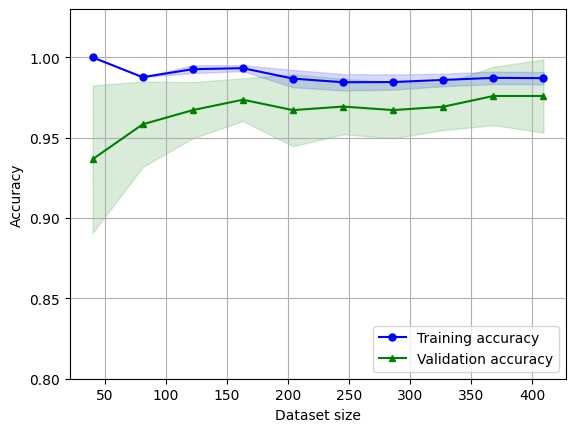

In [10]:
pipe_lr_curves = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', max_iter=10000, solver='liblinear'))

train_sizes, train_score, test_score = learning_curve(estimator=pipe_lr_curves, X=X_train, y=y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=10, n_jobs=1)
train_mean = np.mean(train_score, axis=1)
train_std = np.std(train_score, axis=1)
test_mean = np.mean(test_score, axis=1)
test_std = np.std(test_score, axis=1)
plt.plot(train_sizes, train_mean, color='b', marker='o', markersize=5, label="Training accuracy")
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='g', marker='^', markersize=5, label='Validation accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.grid()
plt.xlabel('Dataset size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.show()


Here in using validation curve to daignoise convergence please be hinted that DO NOT USE L1 regularization technique or you will regret it.

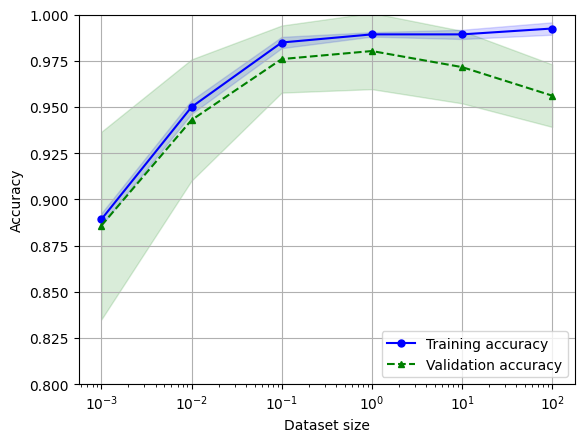

In [11]:
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
pipe_lr_curves = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', max_iter=10000))
train_scores, test_scores = validation_curve(estimator=pipe_lr_curves,X=X_train, y=y_train, param_range=param_range, param_name='logisticregression__C', cv=10)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.plot(param_range, train_mean, color='b', marker='o', markersize=5, label="Training accuracy")
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(param_range, test_mean, color='g', marker='^',linestyle='--' , markersize=5, label='Validation accuracy')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.grid()
plt.xscale('log')
plt.xlabel('Dataset size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.00])
plt.show()



In [12]:
pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))
param_range = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid = [{'svc__C': param_range,
                'svc__kernel': ['linear']},
                {'svc__C': param_range,
                'svc__gamma': param_range,
                'svc__kernel': ['rbf']}]
gs = GridSearchCV(estimator=pipe_svc, param_grid=param_grid, scoring='accuracy', cv=10, refit=True, n_jobs=1)
gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


In [13]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print(f'Test Accuracy: {clf.score(X_test, y_test):0.3f}')

Test Accuracy: 0.974


In [14]:
param_range = scipy.stats.loguniform(0.0001, 1000.0)
np.random.seed(1)
param_range.rvs(10)


array([8.30145146e-02, 1.10222804e+01, 1.00184520e-04, 1.30715777e-02,
       1.06485687e-03, 4.42965766e-04, 2.01289666e-03, 2.62376594e-02,
       5.98924832e-02, 5.91176467e-01])

In [15]:
param_grid = [{'svc__C': param_range,
                'svc__kernel': ['linear']},
                {'svc__C': param_range,
                'svc__gamma': param_range,
                'svc__kernel': ['rbf']}]
rs = RandomizedSearchCV(estimator=pipe_svc, param_distributions=param_grid, refit=True, n_iter=20, n_jobs=None, random_state=1, cv=10,scoring='accuracy')
rs.fit(X_train, y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9780676328502416
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


In [16]:
clf_rs = rs.best_estimator_
print(f'Test Accuracy: {clf_rs.score(X_test, y_test):0.3f}')

Test Accuracy: 0.974


In [17]:
rs = RandomizedSearchCV(estimator=pipe_svc, param_distributions=param_grid, refit=True, n_iter=20, n_jobs=None, random_state=1, cv=2,scoring='accuracy')
scores = cross_val_score(rs, X_train, y_train, scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores)} +- {np.std(scores)}')

CV accuracy: 0.9692307692307693 +- 0.024473689506945145


In [18]:
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


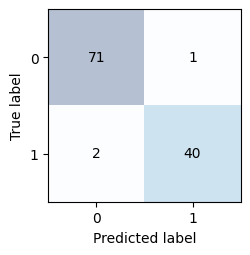

In [19]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [20]:
pre_val = precision_score(y_true=y_test, y_pred=y_pred)
print(f'precision score: {pre_val:0.4f}')
rec_val = recall_score(y_true=y_test, y_pred=y_pred)
print(f'recall score: {rec_val:0.4f}')
f1_val = f1_score(y_true=y_test, y_pred=y_pred)
print(f'f1 score: {f1_val:0.4f}')
math_val = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'matthews corrcoef: {math_val:0.4f}')

precision score: 0.9756
recall score: 0.9524
f1 score: 0.9639
matthews corrcoef: 0.9433


In [21]:
c_gamma_range = [0.01, 0.1, 1, 10]
param_grid = [{'svc__C': c_gamma_range,
                'svc__kernel': ['linear']},
                {'svc__C': c_gamma_range,
                'svc__gamma': c_gamma_range,
                'svc__kernel': ['rbf']}]
scorer = make_scorer(f1_score, pos_label=0)
gs = GridSearchCV(estimator=pipe_svc, param_grid=param_grid, scoring=scorer, cv=10)
gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)


0.9861994953378878
{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


TypeError: unsupported format string passed to tuple.__format__

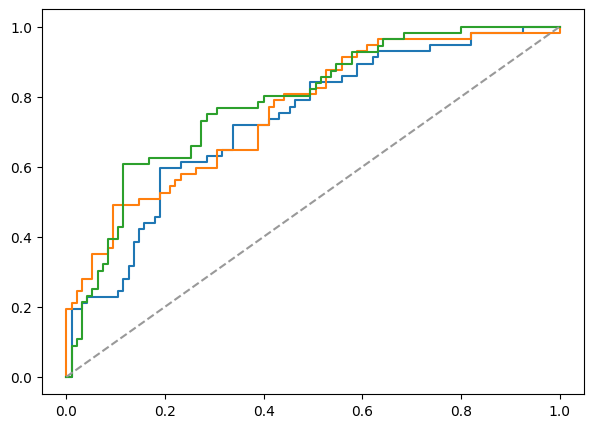

In [22]:
pipe_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(penalty='l2', random_state=1, solver='lbfgs', C=100.0))
X_train2 = X_train[:, [4, 14]]
cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))
fig = plt.figure(figsize=(7, 5))
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []
for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2[train], y_train[train]).predict_proba(X_train2[test])
    fpr, tpr, thresholds = roc_curve(y_train[test], probas[:, 1], pos_label=1)
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC fold {i+1} (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='Random gussing (area=0.5)')
mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = (mean_tpr, mean_fpr)
plt.plot(mean_fpr, mean_tpr, 'k--', label=f'Mean ROC (area = {mean_auc:.2f})', lw=2)
plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='black', label='Perfect Preformance (area=1.0)')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

In [26]:
pre_score = make_scorer(score_func=precision_score, pos_label=1, greater_is_better=True, average='micro')
print(f'{pre_score}')

make_scorer(precision_score, response_method='predict', pos_label=1, average=micro)


In [28]:
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

In [30]:
y_pred = np.zeros(y_imb.shape[0])
np.mean(y_pred == y_imb) * 100

np.float64(89.92443324937027)

In [31]:
print('Number of class 1 examples before: ', X_imb[y_imb == 1].shape[0])

Number of class 1 examples before:  40


In [35]:
X_upsampled, y_upsampled = resample(X_imb[y_imb == 1], y_imb[y_imb == 1], replace=True, n_samples=X_imb[y_imb == 0].shape[0], random_state=123)
print('Number of class 1 examples after: ', X_upsampled.shape[0])

Number of class 1 examples after:  357


In [36]:
X_bal = np.vstack((X[y == 0], X_upsampled))
y_bal = np.hstack((y[y == 0], y_upsampled))
y_pred = np.zeros(y_bal.shape[0])
np.mean(y_pred == y_bal) * 100

np.float64(50.0)